Single-target FMCW range estimation
-----------------------------------
True target range       : 80.00 m
Echo delay              : 0.533 µs
Expected beat frequency : 10.909 MHz
Estimated beat frequency: 10.909 MHz
Estimated range         : 80.00 m


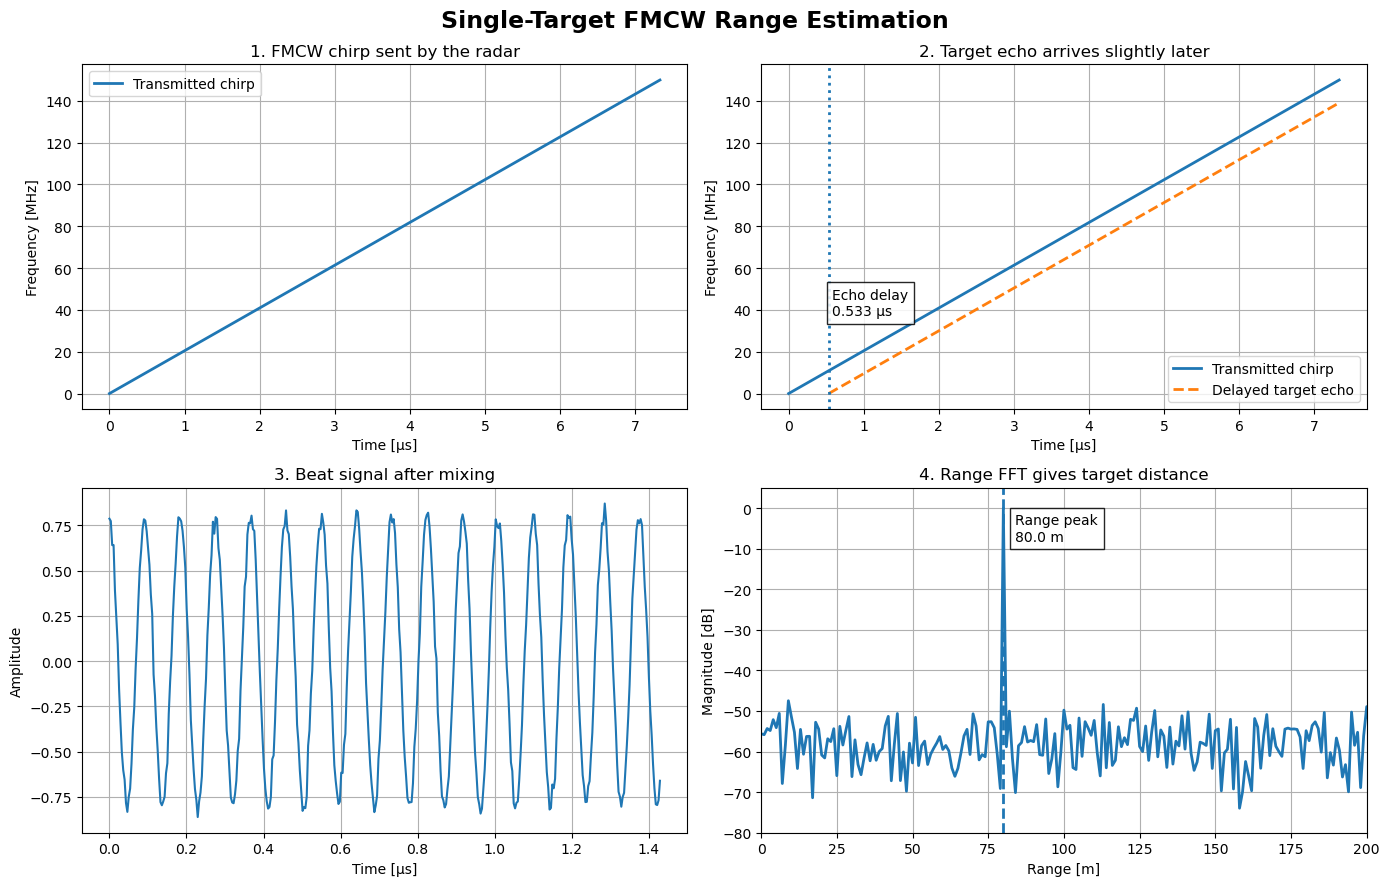

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Single-target FMCW range estimation
#
# Flow:
# 1. Radar sends a chirp
# 2. Target echo comes back delayed
# 3. Mixer creates a beat signal
# 4. Range FFT gives the target distance
# ------------------------------------------------------------

np.random.seed(2)

# ------------------------------------------------------------
# Radar settings
# ------------------------------------------------------------

c = 3e8                  # speed of light [m/s]

max_range = 200          # maximum range for the simulation [m]
range_resolution = 1     # desired range resolution [m]

bandwidth = c / (2 * range_resolution)
chirp_time = 5.5 * 2 * max_range / c
chirp_slope = bandwidth / chirp_time

samples_per_chirp = 2048
sample_rate = samples_per_chirp / chirp_time

t = np.linspace(
    0,
    chirp_time,
    samples_per_chirp,
    endpoint=False
)

# ------------------------------------------------------------
# Single target
# ------------------------------------------------------------

target_range = 80        # meters
target_amplitude = 0.8

# Echo has to travel to the target and back
echo_delay = 2 * target_range / c

# In FMCW radar, this delay becomes a beat frequency
beat_frequency = chirp_slope * echo_delay

# ------------------------------------------------------------
# Transmitted chirp and delayed echo
# ------------------------------------------------------------

# Linear FMCW chirp phase
tx_phase = 2 * np.pi * 0.5 * chirp_slope * t**2
tx_signal = np.cos(tx_phase)

# Received echo is the same chirp, but delayed
echo_time = t - echo_delay
rx_phase = 2 * np.pi * 0.5 * chirp_slope * echo_time**2
rx_signal = target_amplitude * np.cos(rx_phase)

# No echo before the reflected signal reaches the radar
rx_signal[t < echo_delay] = 0

# ------------------------------------------------------------
# Beat signal after mixing
# ------------------------------------------------------------

# For a clean explanation, we show the useful low-frequency beat signal.
# In a real radar receiver, this appears after mixing and low-pass filtering.

beat_signal = target_amplitude * np.cos(
    2 * np.pi * beat_frequency * t
)

# Add small noise so the spectrum looks more realistic
beat_signal += 0.03 * np.random.randn(samples_per_chirp)

# ------------------------------------------------------------
# Range FFT
# ------------------------------------------------------------

beat_fft = np.abs(np.fft.fft(beat_signal))

frequency_axis = np.fft.fftfreq(
    samples_per_chirp,
    d=1 / sample_rate
)

# Keep only positive frequencies
positive_frequency_axis = frequency_axis[:samples_per_chirp // 2]
positive_fft = beat_fft[:samples_per_chirp // 2]

positive_fft_db = 20 * np.log10(
    positive_fft / np.max(positive_fft) + 1e-12
)

# Convert beat-frequency axis into range axis
range_axis = positive_frequency_axis * c / (2 * chirp_slope)

# Find range peak
peak_index = np.argmax(positive_fft)
estimated_beat_frequency = positive_frequency_axis[peak_index]
estimated_range = estimated_beat_frequency * c / (2 * chirp_slope)

print("Single-target FMCW range estimation")
print("-----------------------------------")
print(f"True target range       : {target_range:.2f} m")
print(f"Echo delay              : {echo_delay * 1e6:.3f} µs")
print(f"Expected beat frequency : {beat_frequency / 1e6:.3f} MHz")
print(f"Estimated beat frequency: {estimated_beat_frequency / 1e6:.3f} MHz")
print(f"Estimated range         : {estimated_range:.2f} m")

# ------------------------------------------------------------
# Plot the correct processing sequence
# ------------------------------------------------------------

fig, axs = plt.subplots(2, 2, figsize=(14, 9))
axs = axs.ravel()

# ------------------------------------------------------------
# 1. Chirp frequency ramp
# ------------------------------------------------------------

ax = axs[0]

tx_frequency = chirp_slope * t

ax.plot(
    t * 1e6,
    tx_frequency / 1e6,
    linewidth=2,
    label="Transmitted chirp"
)

ax.set_title("1. FMCW chirp sent by the radar")
ax.set_xlabel("Time [µs]")
ax.set_ylabel("Frequency [MHz]")
ax.grid(True)
ax.legend()

# ------------------------------------------------------------
# 2. Delayed echo from the target
# ------------------------------------------------------------

ax = axs[1]

rx_frequency = chirp_slope * (t - echo_delay)
rx_frequency[t < echo_delay] = np.nan

ax.plot(
    t * 1e6,
    tx_frequency / 1e6,
    linewidth=2,
    label="Transmitted chirp"
)

ax.plot(
    t * 1e6,
    rx_frequency / 1e6,
    "--",
    linewidth=2,
    label="Delayed target echo"
)

ax.axvline(
    echo_delay * 1e6,
    linestyle=":",
    linewidth=2
)

ax.text(
    echo_delay * 1e6 + 0.05,
    np.nanmax(tx_frequency / 1e6) * 0.25,
    f"Echo delay\n{echo_delay * 1e6:.3f} µs",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.85)
)

ax.set_title("2. Target echo arrives slightly later")
ax.set_xlabel("Time [µs]")
ax.set_ylabel("Frequency [MHz]")
ax.grid(True)
ax.legend()

# ------------------------------------------------------------
# 3. Beat signal after mixing
# ------------------------------------------------------------

ax = axs[2]

zoom_samples = 400

ax.plot(
    t[:zoom_samples] * 1e6,
    beat_signal[:zoom_samples],
    linewidth=1.5
)

ax.set_title("3. Beat signal after mixing")
ax.set_xlabel("Time [µs]")
ax.set_ylabel("Amplitude")
ax.grid(True)

# ------------------------------------------------------------
# 4. Range FFT
# ------------------------------------------------------------

ax = axs[3]

ax.plot(
    range_axis,
    positive_fft_db,
    linewidth=2
)

ax.axvline(
    estimated_range,
    linestyle="--",
    linewidth=2
)

ax.text(
    estimated_range + 4,
    -8,
    f"Range peak\n{estimated_range:.1f} m",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.85)
)

ax.set_title("4. Range FFT gives target distance")
ax.set_xlabel("Range [m]")
ax.set_ylabel("Magnitude [dB]")
ax.set_xlim(0, max_range)
ax.set_ylim(-80, 5)
ax.grid(True)

# ------------------------------------------------------------
# Finish
# ------------------------------------------------------------

plt.suptitle(
    "Single-Target FMCW Range Estimation",
    fontsize=17,
    weight="bold"
)

plt.tight_layout()
plt.show()